In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are now expected on the local filesystem. Set LOCAL_DATA_DIR
# (or rely on the notebook's working directory) to point to the folder that
# contains data.csv, predict.csv, etc.

import os
from pathlib import Path

LOCAL_DATA_DIR = Path(os.environ.get("LOCAL_DATA_DIR", Path.cwd())).resolve()
print(f"LOCAL_DATA_DIR set to {LOCAL_DATA_DIR}")

LOCAL_DATA_DIR set to /home/s_sofian/dsai/module_03/dsai-m3-5m-data-3.4-supervised-learning-advanced/kaggle


In [2]:
## Starter Code for Building Baseball Win Prediction Model

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load the pre-processed datasets from the directory pointed to by LOCAL_DATA_DIR
DATA_DIR = LOCAL_DATA_DIR  # defined in the previous cell
print(f"Loading datasets from {DATA_DIR}")

data_df = pd.read_csv(LOCAL_DATA_DIR / "data.csv")
predict_df = pd.read_csv(LOCAL_DATA_DIR / "predict.csv")

# Display basic information about the datasets
print(f"Data set shape: {data_df.shape}")
print(f"Predict set shape: {predict_df.shape}")

Loading datasets from /home/s_sofian/dsai/module_03/dsai-m3-5m-data-3.4-supervised-learning-advanced/kaggle
Data set shape: (1812, 51)
Predict set shape: (453, 45)


In [3]:
# Select only the default features from DATA_DESCRIPTION.md
default_features = [
    # Basic Statistics
    'G', 'R', 'AB', 'H', '2B', '3B', 'HR', 'BB', 'SO', 'SB', 'CS', 'HBP', 'SF',
    'RA', 'ER', 'ERA', 'CG', 'SHO', 'SV', 'IPouts', 'HA', 'HRA', 'BBA', 'SOA',
    'E', 'DP', 'FP', 'attendance', 'BPF', 'PPF',
    
    # Derived Features
    'R_per_game', 'RA_per_game', 'mlb_rpg',
    
    # Era Indicators
    'era_1', 'era_2', 'era_3', 'era_4', 'era_5', 'era_6', 'era_7', 'era_8',
    
    # Decade Indicators
    'decade_1910', 'decade_1920', 'decade_1930', 'decade_1940', 'decade_1950',
    'decade_1960', 'decade_1970', 'decade_1980', 'decade_1990', 'decade_2000', 'decade_2010'
]

# Filter features that exist in both datasets
available_features = [col for col in default_features if col in data_df.columns and col in predict_df.columns]
print(f"Number of available default features: {len(available_features)}")

# Separate features and target variable
X = data_df[available_features]
y = data_df['W']

# Perform the split (adjust test_size / random_state as needed)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% for testing
    random_state=42    # ensures reproducibility
)


Number of available default features: 44


In [4]:
# Scale features
# Identify columns to exclude from scaling (one-hot encoded and label columns)
one_hot_cols = [col for col in X_train.columns if col.startswith(('era_', 'decade_'))]
other_cols = [col for col in X_train.columns if col not in one_hot_cols]

# Scale only non-one-hot features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[other_cols] = scaler.fit_transform(X_train[other_cols])
X_test_scaled[other_cols] = scaler.transform(X_test[other_cols])

In [5]:
# Build Linear Regression Model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_train_preds = lr.predict(X_train_scaled)
lr_test_preds = lr.predict(X_test_scaled)

In [6]:
# Evaluate Linear Regression
lr_train_mae = mean_absolute_error(y_train, lr_train_preds)
lr_test_mae = mean_absolute_error(y_test, lr_test_preds)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_test_preds))
lr_test_r2 = r2_score(y_test, lr_test_preds)

print(f"Linear Regression Performance:")
print(f"  Training MAE: {lr_train_mae:.4f}")
print(f"  Test MAE: {lr_test_mae:.4f}")
print(f"  Test RMSE: {lr_test_rmse:.4f}")
print(f"  Test R²: {lr_test_r2:.4f}")

# Feature importance from Linear Regression
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

Linear Regression Performance:
  Training MAE: 2.6625
  Test MAE: 2.8925
  Test RMSE: 3.6456
  Test R²: 0.9172

Top 10 Most Important Features:
        Feature  Coefficient
1             R     8.813970
16       IPouts     6.249489
2            AB    -6.225434
10           RA    -6.012029
15           SV     4.098789
13           CG     3.303077
11           ER    -3.282859
3             H     3.253957
12          ERA     3.086878
34  decade_1920    -2.916170


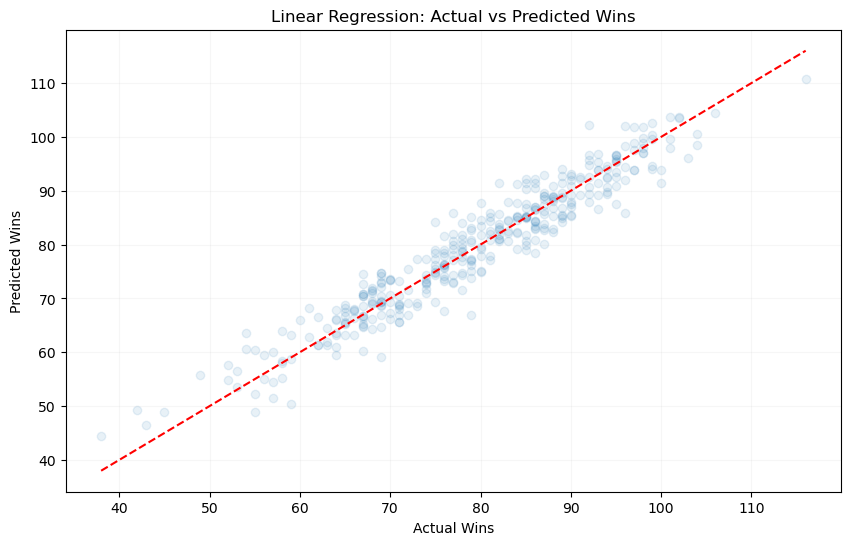

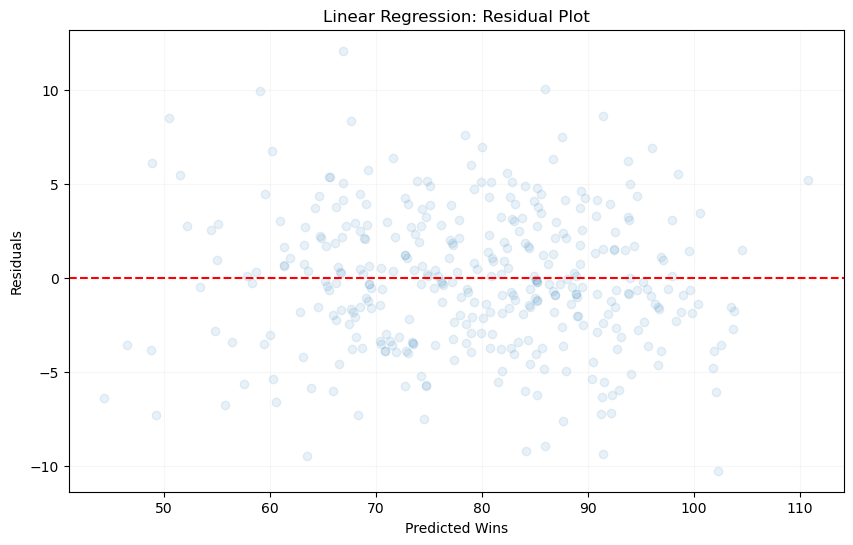

In [35]:
# Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, lr_test_preds, alpha=0.1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Wins')
plt.ylabel('Predicted Wins')
plt.title('Linear Regression: Actual vs Predicted Wins')
plt.grid(True, alpha=0.1)

# Add residual plot
plt.figure(figsize=(10, 6))
residuals = y_test - lr_test_preds
plt.scatter(lr_test_preds, residuals, alpha=0.1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Wins')
plt.ylabel('Residuals')
plt.title('Linear Regression: Residual Plot')
plt.grid(True, alpha=0.1)
plt.show()

In [37]:
# Prepare Submission

# Align features and scale using the previously fitted scaler
predict_scaled = predict_df[available_features].copy()
predict_scaled[other_cols] = scaler.transform(predict_scaled[other_cols])

# Predict wins for the new dataset
predict_preds = lr.predict(predict_scaled)

# Build submission in the same format as submission.csv
submission_df = pd.DataFrame({
    'ID': predict_df['ID'],
    'W': np.round(predict_preds).astype(int)
})

submission_path = 'submission_predict10.csv'
submission_df.to_csv(submission_path, index=False)
print(f"Kaggle submission saved to {submission_path}")

Kaggle submission saved to submission_predict10.csv
